In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [3]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r
import random
import harmonypy as hm
import anndata2ri

In [ ]:
sc.settings.seed = 42

In [ ]:
np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [15]:
%reload_ext rpy2.ipython

In [ ]:
%%R
library(reticulate)

use_python(
  "/home/aumlauf/miniforge3/envs/circ_iri/bin/python",
  required = TRUE
)

py_config()

python:         /home/aumlauf/miniforge3/envs/circ_iri/bin/python
libpython:      NA
pythonhome:     /home/aumlauf/miniforge3/envs/circ_iri:/home/aumlauf/miniforge3/envs/circ_iri
version:        3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
numpy:          /home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/numpy
numpy_version:  2.4.3

NOTE: Python version was forced by the current process


## Load TXT file with barcodes of myeloid cells

In [ ]:
barcodes = pd.read_csv(
    "/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/myeloid_barcodes.txt",
    header=None
)[0].tolist()

## load raw, concat and filtered adata

In [ ]:

adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis_final/adata_concat_raw_filtered.h5ad")

## subset adata for barcodes of myeloid cells

In [ ]:
adata = adata[adata.obs_names.isin(barcodes)].copy()

In [ ]:
#überprüfen, ob alles korrekt ist: beide Zahlen sollten übereinstimmen
len(barcodes), adata.n_obs

(13377, 13377)

## Repeat normalization scran

In [17]:
%%R
library(scran)
library(BiocParallel)

Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [ ]:
# Preliminary clustering for differentiated normalisation
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(
    adata_pp, key_added="groups", flavor="igraph", n_iterations=2, directed=False
)

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()
    # Convert sparse matrix to dense numpy array
    data_mat = data_mat.toarray()

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv["data_mat"] = data_mat

with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv["input_groups"] = adata_pp.obs["groups"]

In [ ]:
del adata_pp

In [17]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [ ]:
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
scran_logged = np.log1p(scran)
adata.layers["scran_normalization"] = csr_matrix(scran_logged)

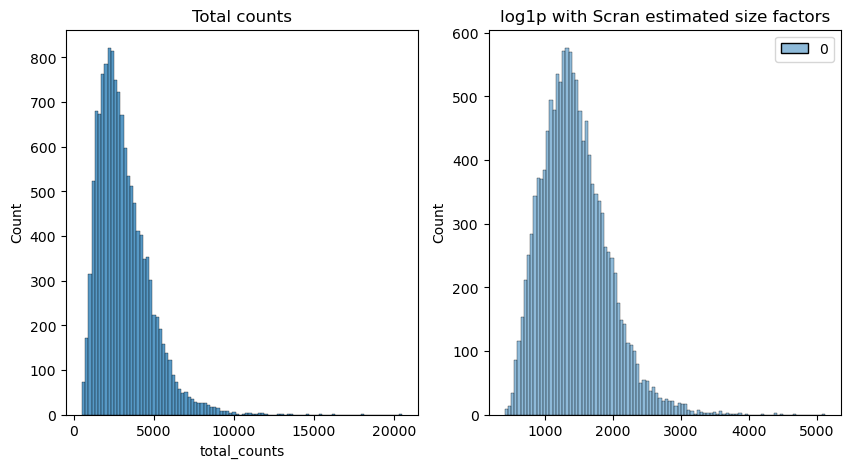

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("log1p with Scran estimated size factors")
plt.show()

In [21]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/normalization_histogram_scran_normalization_plot.png")

<Figure size 640x480 with 0 Axes>

## Feature selection

In [22]:
%%R
library(scry)
library(SingleCellExperiment)

In [ ]:
X_sparse = adata.X.T.tocoo()

Matrix = rpackages.importr("Matrix")

with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    ro.globalenv["obs"] = adata.obs
    ro.globalenv["var"] = adata.var

i, j = X_sparse.row, X_sparse.col
x = X_sparse.data

ro.globalenv["i"] = ro.IntVector((i + 1).tolist())  # R is 1-indexed
ro.globalenv["j"] = ro.IntVector((j + 1).tolist())
ro.globalenv["x"] = ro.FloatVector(x.tolist())

r("X <- sparseMatrix(i = i, j = j, x = x, dims = c({}, {}))".format(*X_sparse.shape))

In [25]:
%%R
print(dim(X))
print(dim(obs))
print(dim(var))


[1] 20681 13377
[1] 13377    26
[1] 20681    13


In [26]:
%%R
sce <- SingleCellExperiment(
  assays = list(X = X),
  colData = obs,
  rowData = var
)


In [27]:
%%R
sce <- devianceFeatureSelection(sce, assay = "X")

In [28]:
with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    binomial_deviance = ro.r("rowData(sce)$binomial_deviance")

In [ ]:
idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata.var_names.shape, dtype=bool)
mask[idx] = True

adata.var["highly_deviant"] = mask
adata.var["binomial_deviance"] = binomial_deviance

In [ ]:
sc.pp.highly_variable_genes(adata, layer="scran_normalization", batch_key = "sample")

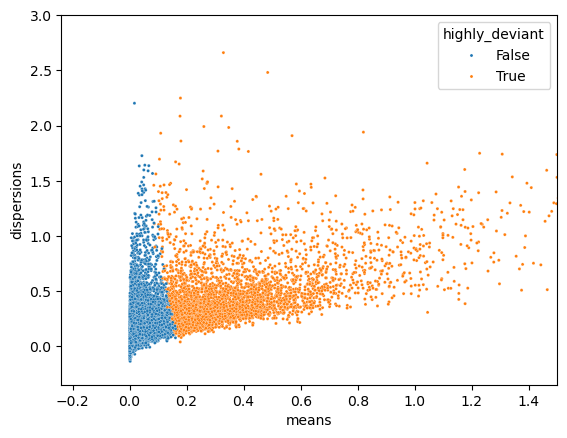

In [ ]:
ax = sns.scatterplot(
    data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 1.5)
ax.set_ylim(None, 3)
plt.show()

In [32]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/feature_selection_plot.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
adata.var["highly_deviant"].sum()

np.int64(4000)

In [ ]:
adata.write("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/adata_myeloid_normalization_feature_selection.h5ad")

## PCA

In [6]:
adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/adata_myeloid_normalization_feature_selection.h5ad")

In [7]:
adata.X = adata.layers["scran_normalization"]

In [8]:
adata.var["highly_variable"] = adata.var["highly_deviant"]
sc.pp.pca(adata, svd_solver="arpack", mask_var="highly_variable", n_comps= 200)

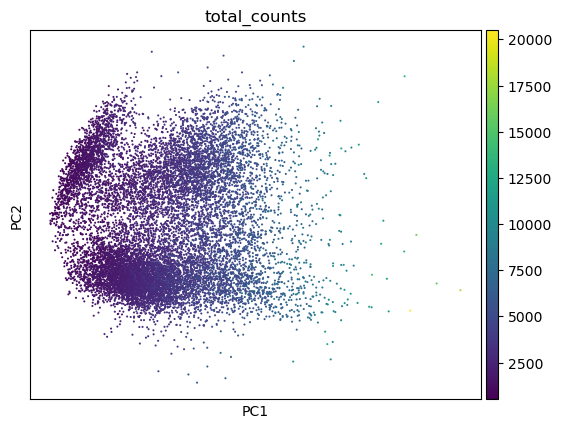

In [10]:
sc.pl.pca_scatter(adata, color="total_counts", show = False)
plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/PCA_total_counts_1_2_plot.png")

## Elbowplot

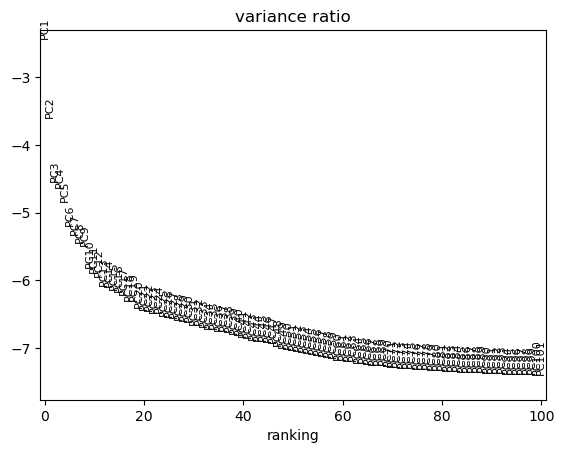

In [11]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=100, show = False)
plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/PCA_Elbow_plot.png")

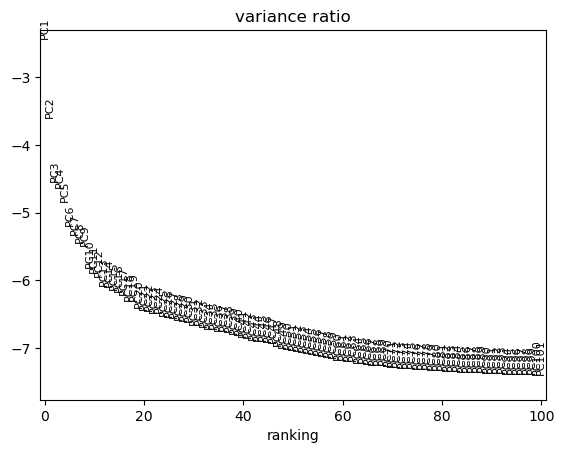

In [ ]:
# elbow plot
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=100)

## Harmony batch correction

In [12]:
# Get PCs from the AnnData object
pcs = adata.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

(13377, 200)


In [13]:
# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs[:, 0:50], adata.obs, "sample", max_iter_harmony = 20)

2026-04-24 16:24:22,923 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-04-24 16:24:22,924 - harmonypy - INFO -   Parameters:
2026-04-24 16:24:22,925 - harmonypy - INFO -     max_iter_harmony: 20
2026-04-24 16:24:22,926 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-24 16:24:22,927 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-24 16:24:22,928 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-24 16:24:22,929 - harmonypy - INFO -     nclust: 100
2026-04-24 16:24:22,929 - harmonypy - INFO -     block_size: 0.05
2026-04-24 16:24:22,931 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-04-24 16:24:22,932 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-04-24 16:24:22,932 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-24 16:24:22,933 - harmonypy - INFO -     verbose: True
2026-04-24 16:24:22,934 - harmonypy - INFO -     random_state: 0
2026-04-24 16:24:22,935 - harmonypy - INFO -   Data: 50 PCs × 13377 cells


In [14]:
# Store corrected PCs back in the AnnData object
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr

## UMAP 

In [15]:
# Use harmonized PCs for downstream analysis
sc.pp.neighbors(adata, use_rep='X_pca_harmony', random_state=42)
sc.tl.umap(adata, random_state=42)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, random_state=42)

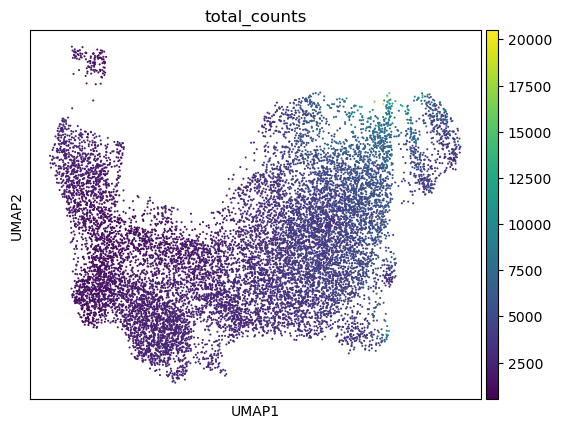

In [16]:

sc.pl.umap(adata, color="total_counts", show = False)
plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/UMAP_total_counts_batch_corrected_plot.png")

## Inspecting quality control metrics

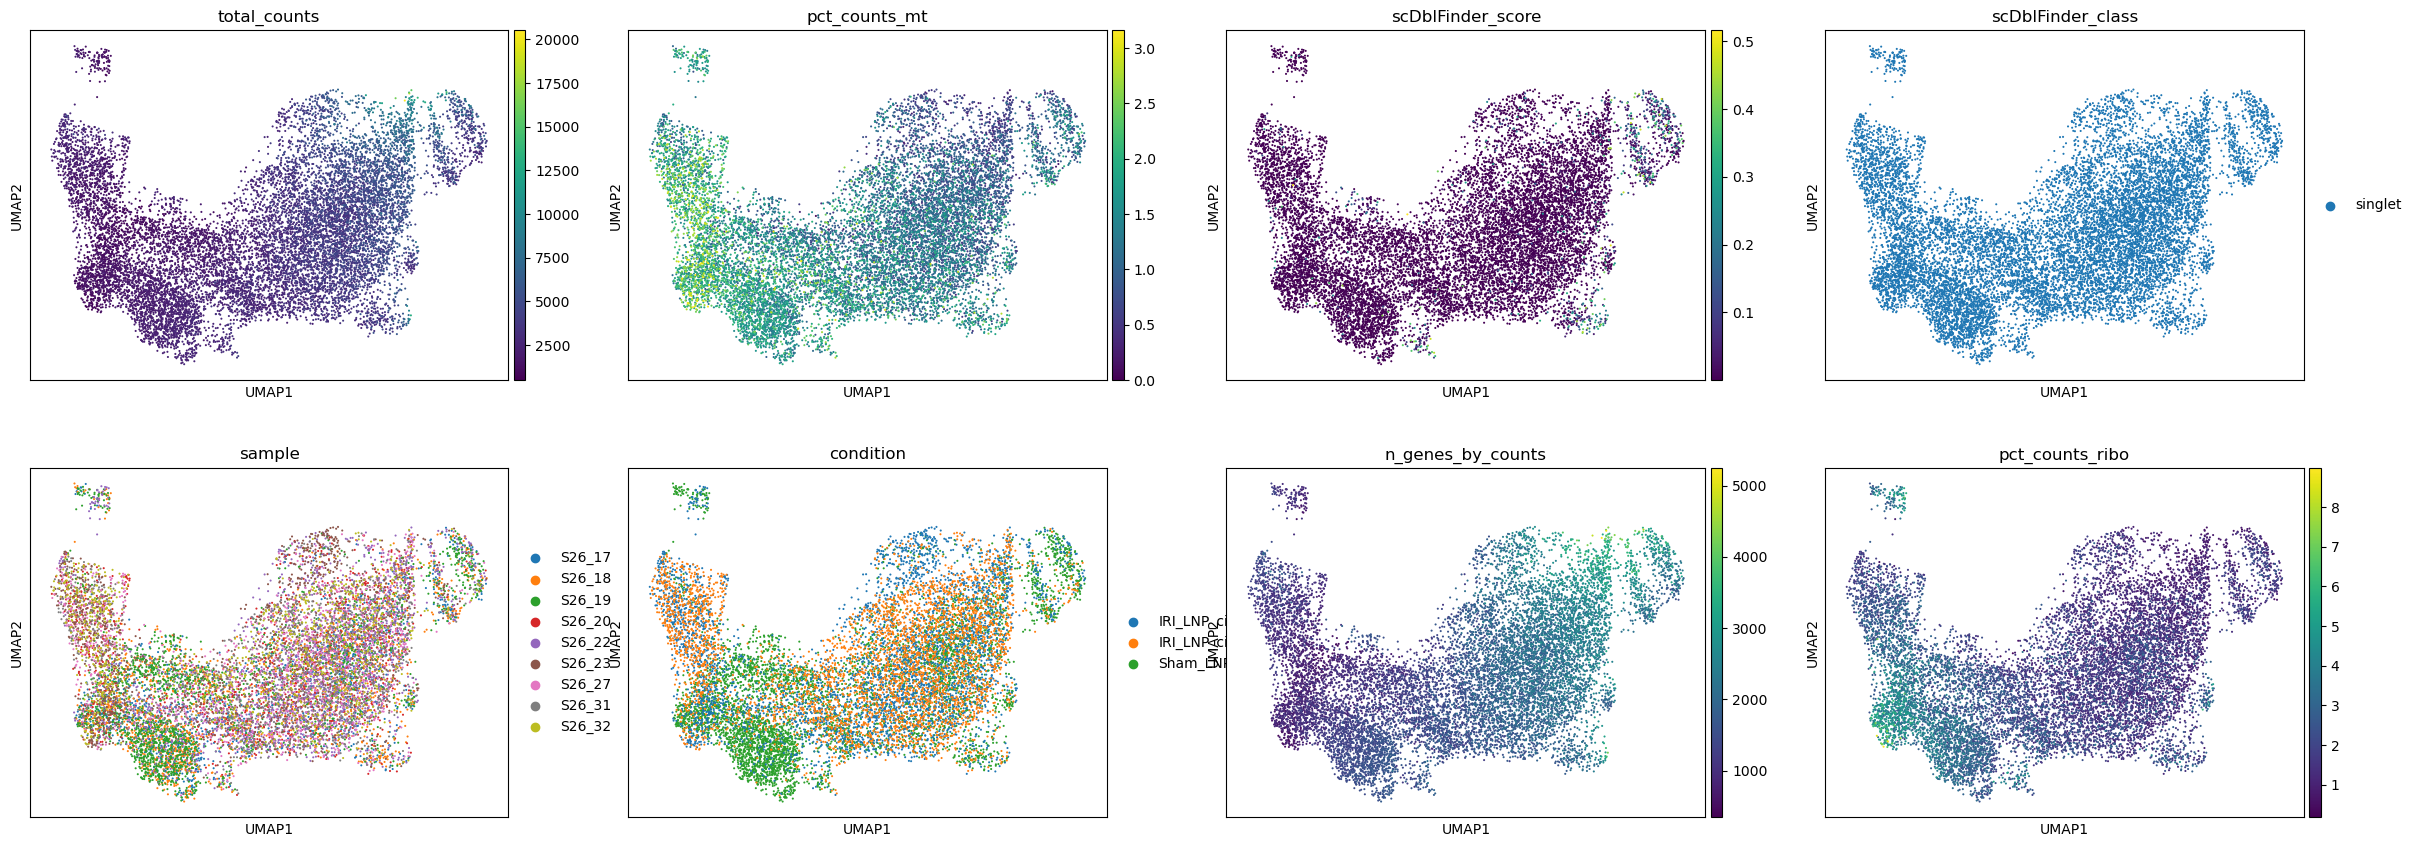

In [18]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "scDblFinder_score", "scDblFinder_class", "sample", "condition", "n_genes_by_counts", "pct_counts_ribo"],
    show = False
)

plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/UMAP_overview_batch_corrected_plot.png")

## Subclustering

In [20]:
sc.tl.leiden(
    adata, key_added="leiden_res0_1", resolution=0.1, flavor="igraph", n_iterations=2, random_state=42
)
sc.tl.leiden(
    adata, key_added="leiden_res0_25", resolution=0.25, flavor="igraph", n_iterations=2, random_state=42
)
sc.tl.leiden(
    adata, key_added="leiden_res0_3", resolution=0.3, flavor="igraph", n_iterations=2, random_state=42
)
sc.tl.leiden(
    adata, key_added="leiden_res0_5", resolution=0.5, flavor="igraph", n_iterations=2, random_state=42
)

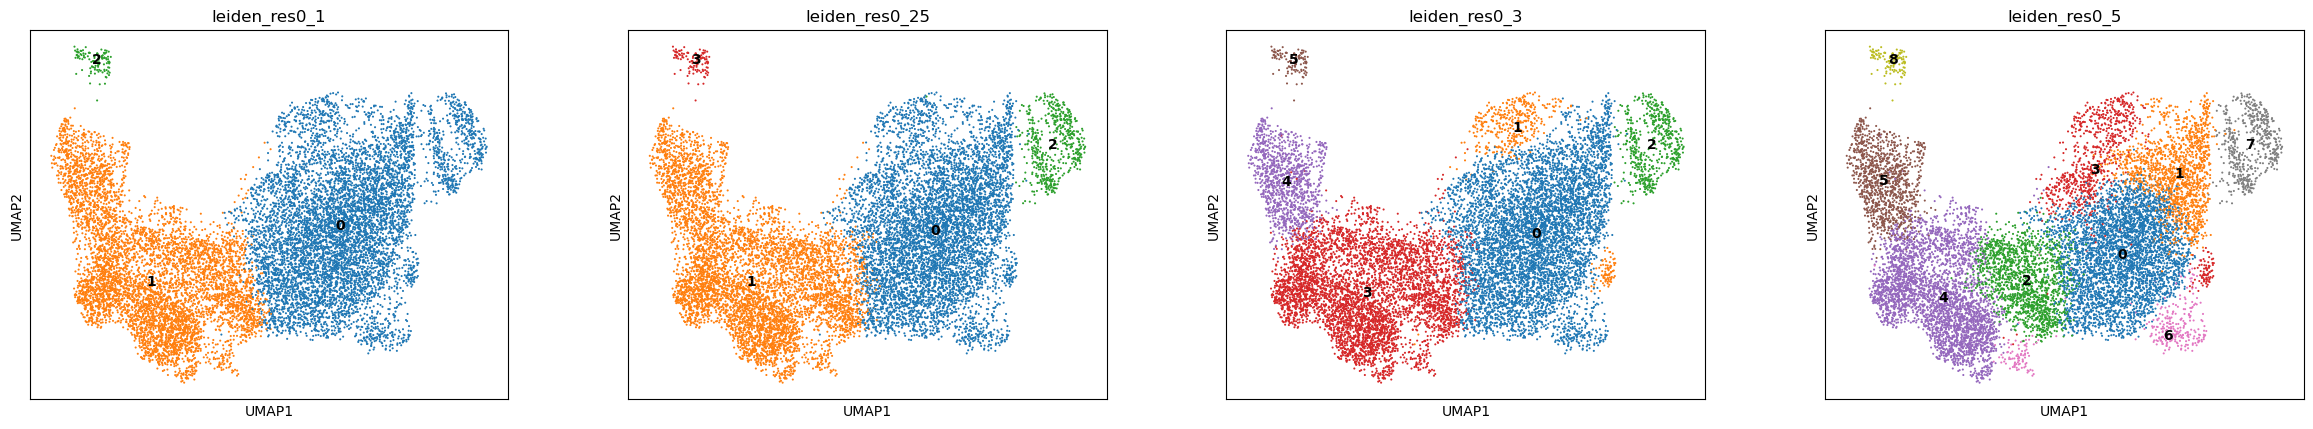

In [21]:
sc.pl.umap(
    adata,
    color=["leiden_res0_1", "leiden_res0_25", "leiden_res0_3", "leiden_res0_5"],
    legend_loc="on data",
    show = False
)

plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/UMAP_different_res_0_1_0_25_0_3_0_5_batch_corrected.png")

## comparison different Leiden resolution

In [65]:
metrics = [
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_ribo",
    "pct_counts_mt"
]

In [ ]:

df = adata.obs[["leiden_res0_25"] + metrics].copy()

df_long = df.melt(
    id_vars="leiden_res0_25",
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

/tmp/ipykernel_2693871/2961295527.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


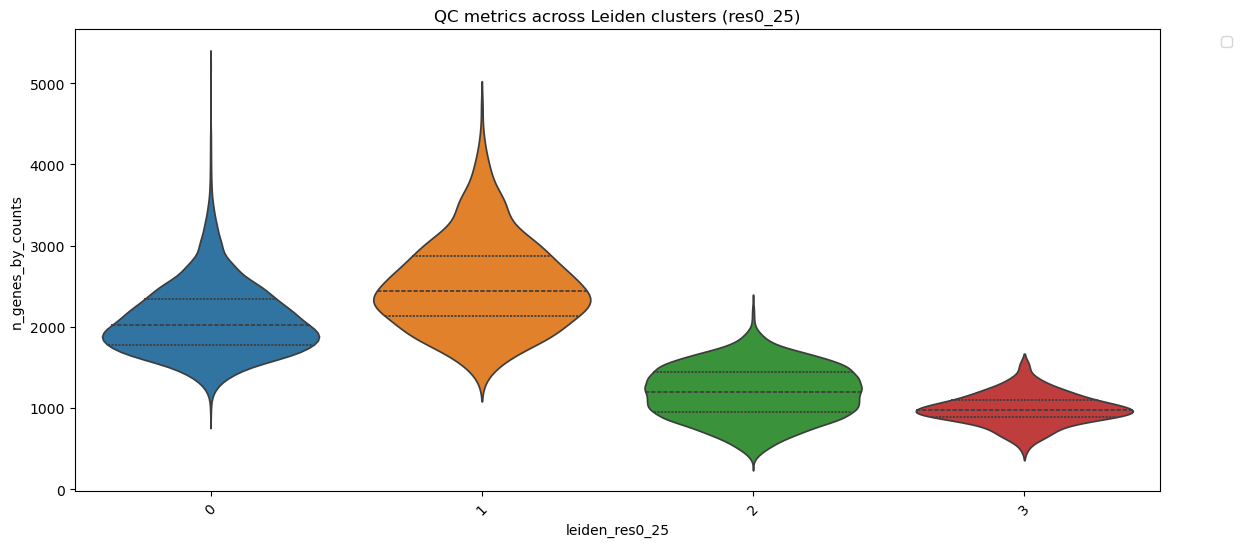

In [67]:
plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="leiden_res0_25",
    y="n_genes_by_counts",
    hue="leiden_res0_25",
    split=False,
    inner="quartile"
)

plt.xticks(rotation=45)
plt.title("QC metrics across Leiden clusters (res0_25)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/leiden_res0_25_comparison_qc_metric_n_genes_by_counts_batch_corrected_plot.png")

## Cell cycle - Scoring

# dafür müssen wir noch zusätzlich normalization laufen lassen 

In [ ]:
#with open("/home/aumlauf/scripts/sc_analysis_final/cell_cycle_genes_regev_lab.txt", "r", encoding="utf-8") as f:
#    cell_cycle_genes = f.read().splitlines()

#print(cell_cycle_genes)

In [ ]:
#cell_cycle_genes = [gene.capitalize() for gene in cell_cycle_genes]

In [ ]:
#s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
#g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]
#cell_cycle_genes = [*s_genes, *g2m_genes]

In [ ]:
#adata_cc = adata.copy()
#adata_cc.X = adata_cc.layers["log1p_norm"]

In [ ]:
#sc.tl.score_genes_cell_cycle(adata_cc, s_genes=s_genes, g2m_genes=g2m_genes)

In [ ]:
#sc.pl.umap(
#    adata_cc,
#    color=["leiden_res0_25", "phase"],
    #legend_loc="on data",
#)

In [ ]:
#plt.savefig("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/UMAP_leiden_res0_25_cell_cycle_phase_batch_corrected_plot.png")

In [ ]:
#adata.write("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/adata_myeloid_dim_reduction_cellcycle_scoring_clustering_batch_corrected.h5ad")

## Markergenes

In [84]:
marker_genes_myeloid_cells = {
    "M1_MAC-Mo": ["Ly6c2", "S100a8"],
    "M2_MAC‑TR": ["Spp1", "Gpnmb"],
    "Bhlhe41+MΦ;": ["Fabp5"],
    "MAC‑Gpnmb": ["Folr2"],
    "Dongchao": ["Ccr2", "Pde4d", "Plcb1", "Dock5", "F10", "Ctnnd2", "Tnfsf8", "Cxcl9"],
    
}

## Dotplot

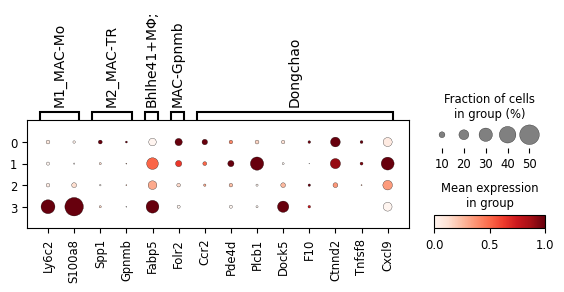

In [ ]:
# 4) Dotplot grouped by Leiden clusters (0–15)
sc.pl.dotplot(
    adata,
    var_names=marker_genes_myeloid_cells,
    groupby="leiden_res0_25",
    standard_scale="var",
    dendrogram=False
)

## UMAP

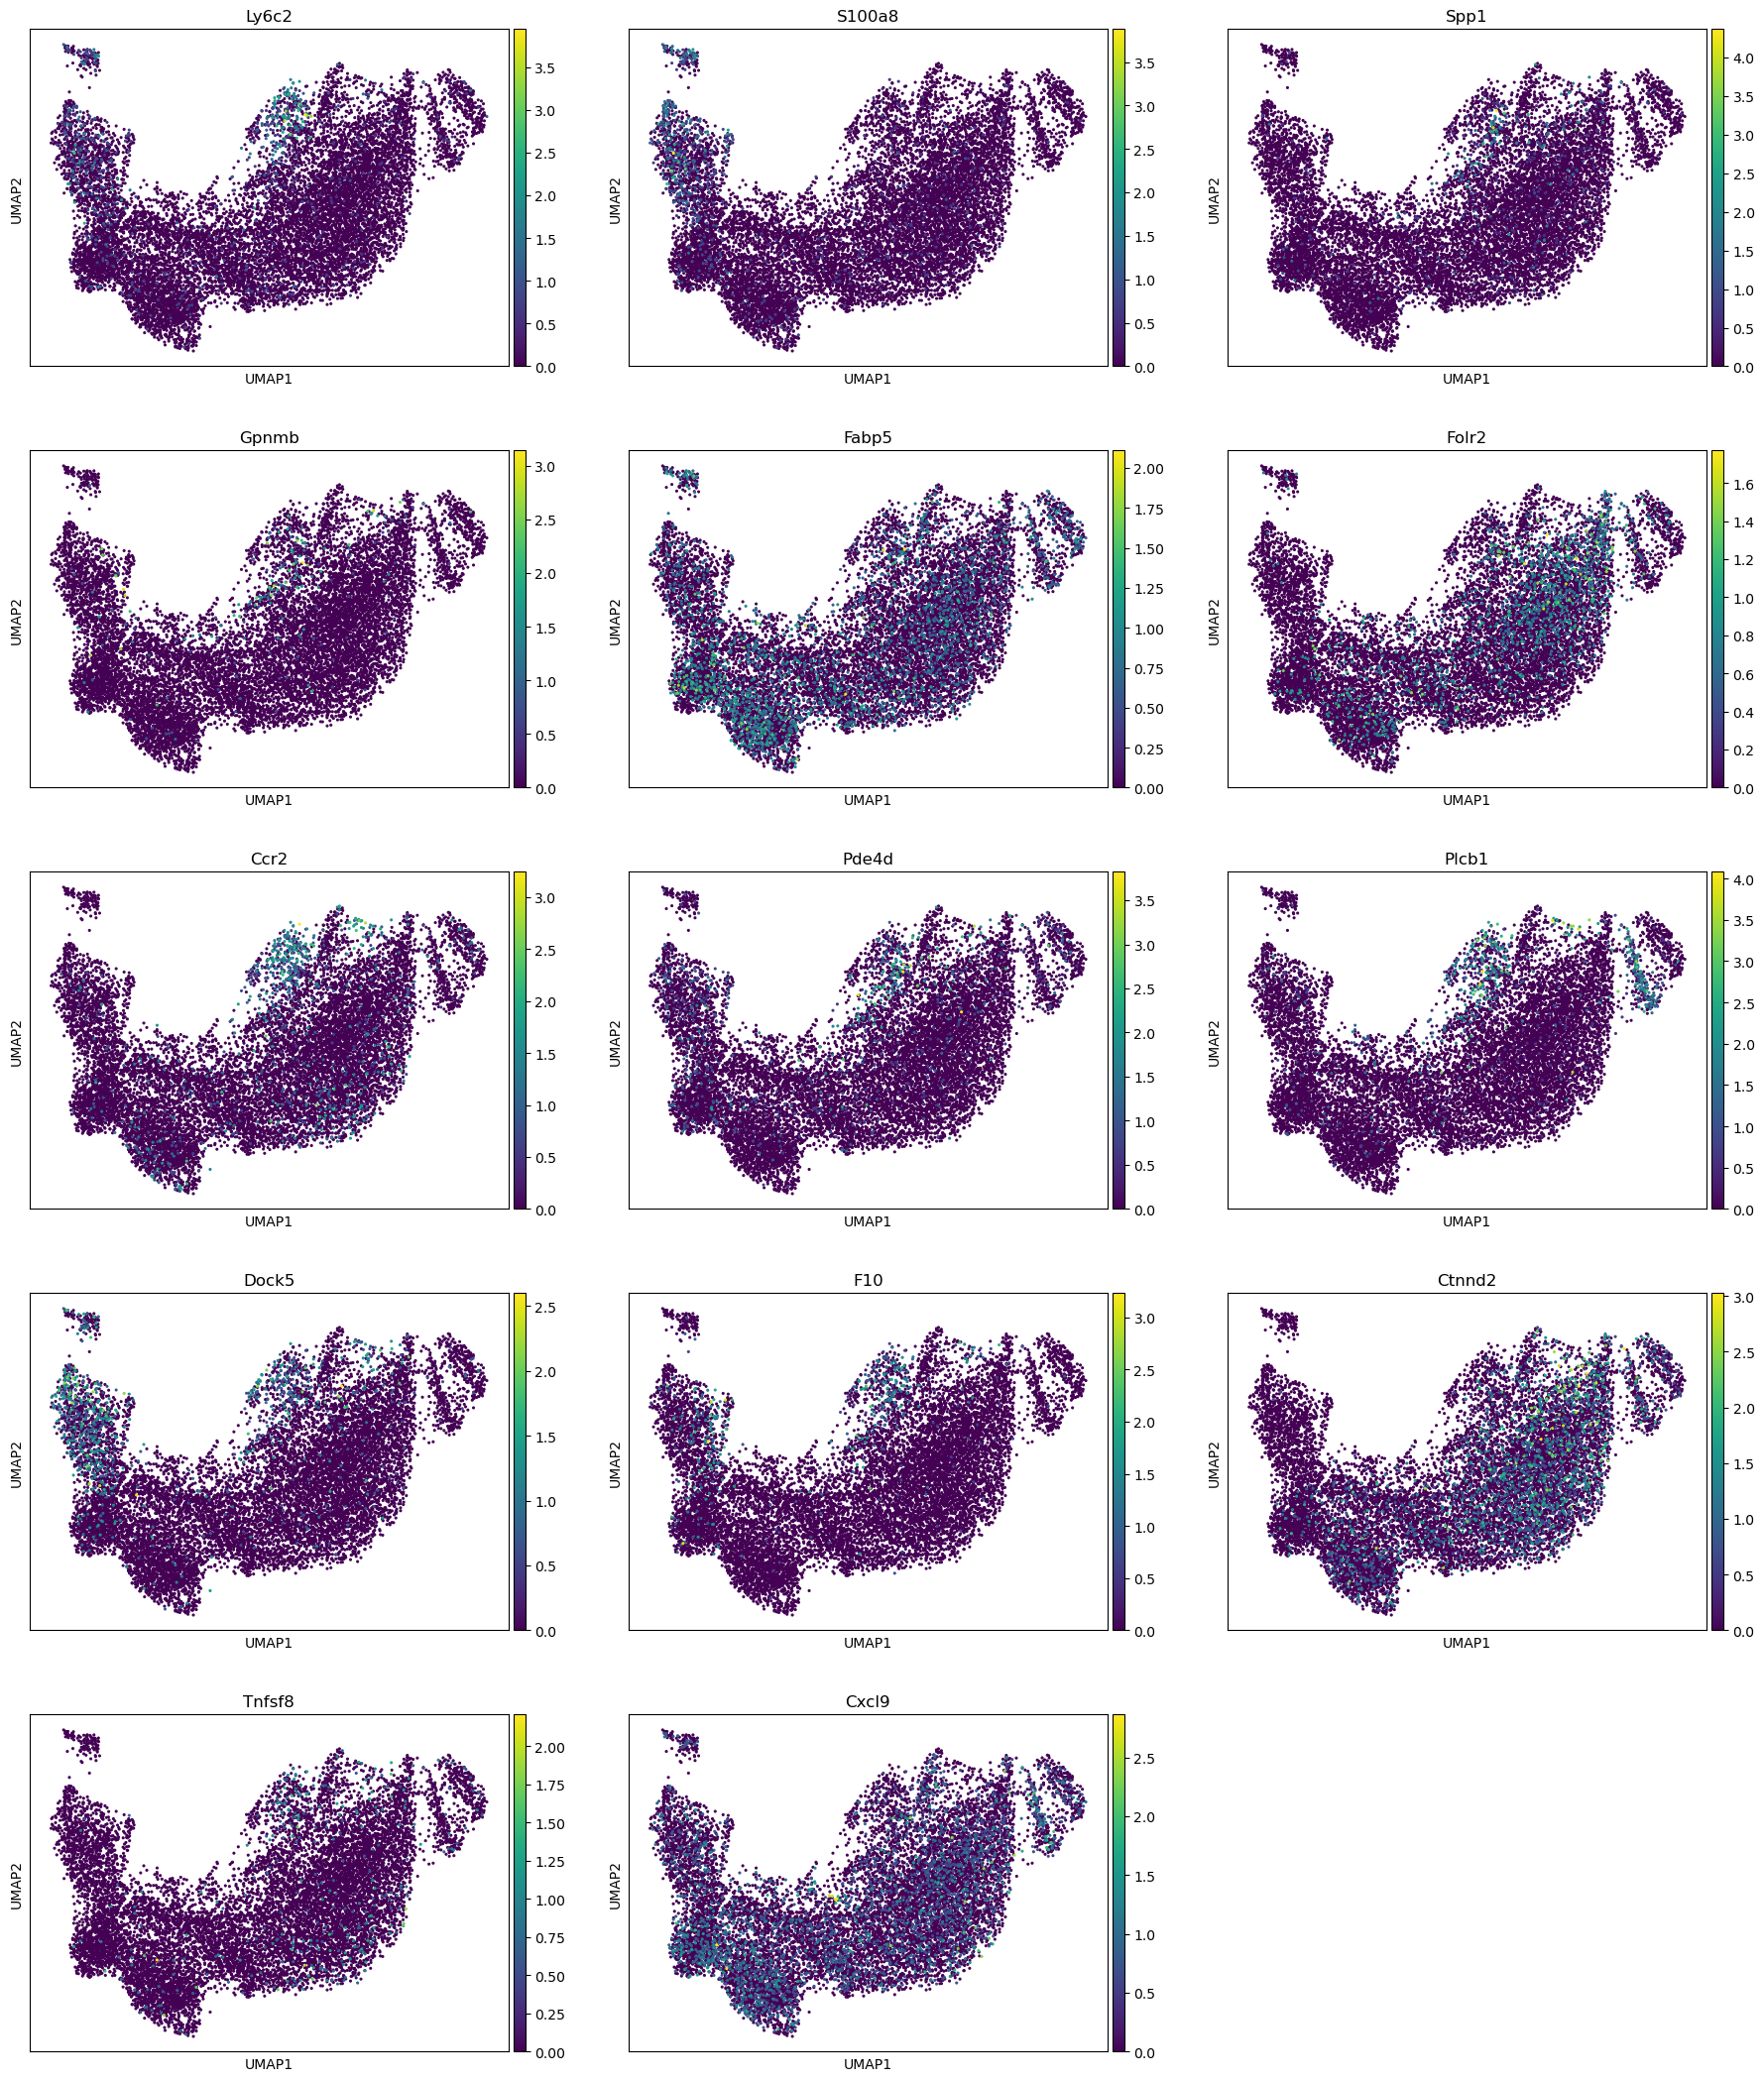

In [ ]:
# Flatten gene list (for Scanpy plotting)
all_genes = sorted(set(g for genes in marker_genes_myeloid_cells.values() for g in genes))

# enforce NON-alphabetical order (your defined order)
ordered_genes = []
for cell_type in marker_genes_myeloid_cells:
    ordered_genes.extend(marker_genes_myeloid_cells[cell_type])

# keep only genes present in dataset, preserving order
ordered_genes = [g for g in ordered_genes if g in adata.var_names]

# UMAP feature plots in exact order
sc.pl.umap(
    adata,
    color=ordered_genes,
    ncols=3,
    cmap="viridis",
    size=20
)

## rank Top20 genes to identify cluster

In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden_res0_25",
    method="wilcoxon"
)

In [ ]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False
)

## Annotation of subcluster

In [ ]:
cl_annotation = {
    "0": "fibroblasts",
    "1": "fibroblasts",
    "2": "fibroblasts",
    "3": "endothel cells",
    "4": "pericytes",
    "5": "cardiomyocytes",
    "6": "cardiomyocytes",
    "7": "cardiomyocytes",
    "8": "cardiomyocytes",
    "9": "cardiomyocytes",
    "10": "endothel cells",
    "11": "cardiomyocytes",
    "12": "endothel cells",
    "13": "endothel cells",
    "14": "cardiomyocytes",
    "15": "myeloid cells",
    "16": "lymphoid cells",
    "17": "endothel cells",
    "18": "myeloid cells",
    "19": "mesothelial_epithelial cells",
    "20": "neuronal cells",
    "21": "myeloid cells"
}

In [ ]:
# adata.obs["manual_celltype_annotation"] = adata.obs.leiden_res0_25.map(cl_annotation)

In [ ]:
# sc.pl.umap(adata, color=["manual_celltype_annotation"])

In [ ]:
# write MC adata

# write the cellbarcode - subcluster assignment


# differentially expressed genes: edgeR pseudo-bulk

In [ ]:
adata.obs[['sample', 'condition']]

,sample,condition
AAACCCGCATAGAGAG-1-S26_17,S26_17,Sham_LNP_circGFP
AAACGCCTCTCACTTA-1-S26_17,S26_17,Sham_LNP_circGFP
AAACGTCCATCCGCTG-1-S26_17,S26_17,Sham_LNP_circGFP
AAACTCCGTTGAATGG-1-S26_17,S26_17,Sham_LNP_circGFP
AAAGCAATCGCTCAGG-1-S26_17,S26_17,Sham_LNP_circGFP
...,...,...
TGTGCCTCATCCTGCG-1-S26_32,S26_32,IRI_LNP_circINSR
TGTGCGCGTAGCTCGC-1-S26_32,S26_32,IRI_LNP_circINSR
TGTGCGCGTTATCCAA-1-S26_32,S26_32,IRI_LNP_circINSR
TGTGCTGGTTCTGGAT-1-S26_32,S26_32,IRI_LNP_circINSR


In [ ]:
adata.obs["leiden_res0_25"] 

AAACCCGCATAGAGAG-1-S26_17    0
AAACGCCTCTCACTTA-1-S26_17    2
AAACGTCCATCCGCTG-1-S26_17    2
AAACTCCGTTGAATGG-1-S26_17    0
AAAGCAATCGCTCAGG-1-S26_17    0
                            ..
TGTGCCTCATCCTGCG-1-S26_32    0
TGTGCGCGTAGCTCGC-1-S26_32    2
TGTGCGCGTTATCCAA-1-S26_32    0
TGTGCTGGTTCTGGAT-1-S26_32    0
TGTGGTCAGGTAATGA-1-S26_32    0
Name: leiden_res0_25, Length: 13377, dtype: category
Categories (4, object): ['0', '1', '2', '3']

In [ ]:
adata = adata.copy()

In [80]:
# adata.obs["replicate"] = adata.obs["replicate"].astype("category")
adata.obs["condition"] = adata.obs["condition"].astype("category")
adata.obs["sample"] = adata.obs["sample"].astype("category")
adata.obs["leiden_res0_25"] = adata.obs["leiden_res0_25"].astype("category")

In [6]:
NUM_OF_CELL_PER_DONOR = 30


def aggregate_and_filter(
    adata,
    cell_identity,
    donor_key,
    condition_key,
    cell_identity_key,
    obs_to_keep=None,  # which additional metadata to keep, e.g. gender, age, etc.
    replicates_per_patient=1,
):
    # subset adata to the given cell identity
    if obs_to_keep is None:
        obs_to_keep = []
    adata_cell_pop = adata[adata.obs[cell_identity_key] == cell_identity].copy()
    # check which donors to keep according to the number of cells specified with NUM_OF_CELL_PER_DONOR
    size_by_donor = adata_cell_pop.obs.groupby([donor_key]).size()
    donors_to_drop = [
        donor
        for donor in size_by_donor.index
        if size_by_donor[donor] <= NUM_OF_CELL_PER_DONOR
    ]
    if len(donors_to_drop) > 0:
        print("Dropping the following samples:")
        print(donors_to_drop)
    df = pd.DataFrame(columns=[*adata_cell_pop.var_names, *obs_to_keep])

    adata_cell_pop.obs[donor_key] = adata_cell_pop.obs[donor_key].astype("category")
    for i, donor in enumerate(donors := adata_cell_pop.obs[donor_key].cat.categories):
        print(f"\tProcessing donor {i+1} out of {len(donors)}...", end="\r")
        if donor not in donors_to_drop:
            adata_donor = adata_cell_pop[adata_cell_pop.obs[donor_key] == donor]
            # create replicates for each donor
            indices = list(adata_donor.obs_names)
            random.shuffle(indices)
            indices = np.array_split(np.array(indices), replicates_per_patient)
            for i, rep_idx in enumerate(indices):
                adata_replicate = adata_donor[rep_idx]
                # specify how to aggregate: sum gene expression for each gene for each donor and also keep the condition information
                agg_dict = dict.fromkeys(adata_replicate.var_names, "sum")
                for obs in obs_to_keep:
                    agg_dict[obs] = "first"
                # create a df with all genes, donor and condition info
                df_donor = pd.DataFrame(adata_replicate.X.toarray())
                df_donor.index = adata_replicate.obs_names
                df_donor.columns = adata_replicate.var_names
                df_donor = df_donor.join(adata_replicate.obs[obs_to_keep])
                # aggregate
                df_donor = df_donor.groupby(donor_key).agg(agg_dict)
                df_donor[donor_key] = donor
                df.loc[f"donor_{donor}_{i}"] = df_donor.loc[donor]
    print("\n")
    # create AnnData object from the df
    adata_cell_pop = sc.AnnData(
        df[adata_cell_pop.var_names], obs=df.drop(columns=adata_cell_pop.var_names)
    )
    return adata_cell_pop

In [83]:
obs_to_keep = ["leiden_res0_25", "condition", "sample"]

In [84]:
adata.X = adata.layers["soupX_counts"].copy()

In [85]:
cell_type = adata.obs["leiden_res0_25"].cat.categories[0]

In [31]:
cell_type

'0'

In [87]:
# process first cell type separately...
cell_type = adata.obs["leiden_res0_25"].cat.categories[0]
print(
    f'Processing {cell_type} (1 out of {len(adata.obs["leiden_res0_25"].cat.categories)})...'
)
adata_pb = aggregate_and_filter(adata,
    cell_type,
    "sample",
    "condition",
    "leiden_res0_25",
    replicates_per_patient=1, obs_to_keep=obs_to_keep)
for i, cell_type in enumerate(adata.obs["leiden_res0_25"].cat.categories[1:]):
    print(
        f'Processing {cell_type} ({i+2} out of {len(adata.obs["leiden_res0_25"].cat.categories)})...'
    )
    adata_cell_type = aggregate_and_filter(adata,
    cell_type,
    "sample",
    "condition",
    "leiden_res0_25",
    replicates_per_patient=1, obs_to_keep=obs_to_keep)
    adata_pb = adata_pb.concatenate(adata_cell_type)

Processing 0 (1 out of 4)...


/tmp/ipykernel_1215673/509313728.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_by_donor = adata_cell_pop.obs.groupby([donor_key]).size()


/tmp/ipykernel_1215673/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_1215673/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_1215673/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


...

/tmp/ipykernel_1215673/956525985.py:22: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_pb = adata_pb.concatenate(adata_cell_type)
/tmp/ipykernel_1215673/509313728.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_by_donor = adata_cell_pop.obs.groupby([donor_key]).size()


Processing 3 (4 out of 4)...
Dropping the following samples:
['S26_17', 'S26_18']


/tmp/ipykernel_1215673/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_1215673/509313728.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_donor = df_donor.groupby(donor_key).agg(agg_dict)


/tmp/ipykernel_1215673/956525985.py:22: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_pb = adata_pb.concatenate(adata_cell_type)


In [88]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21366089 stored elements and shape (13377, 20681)>

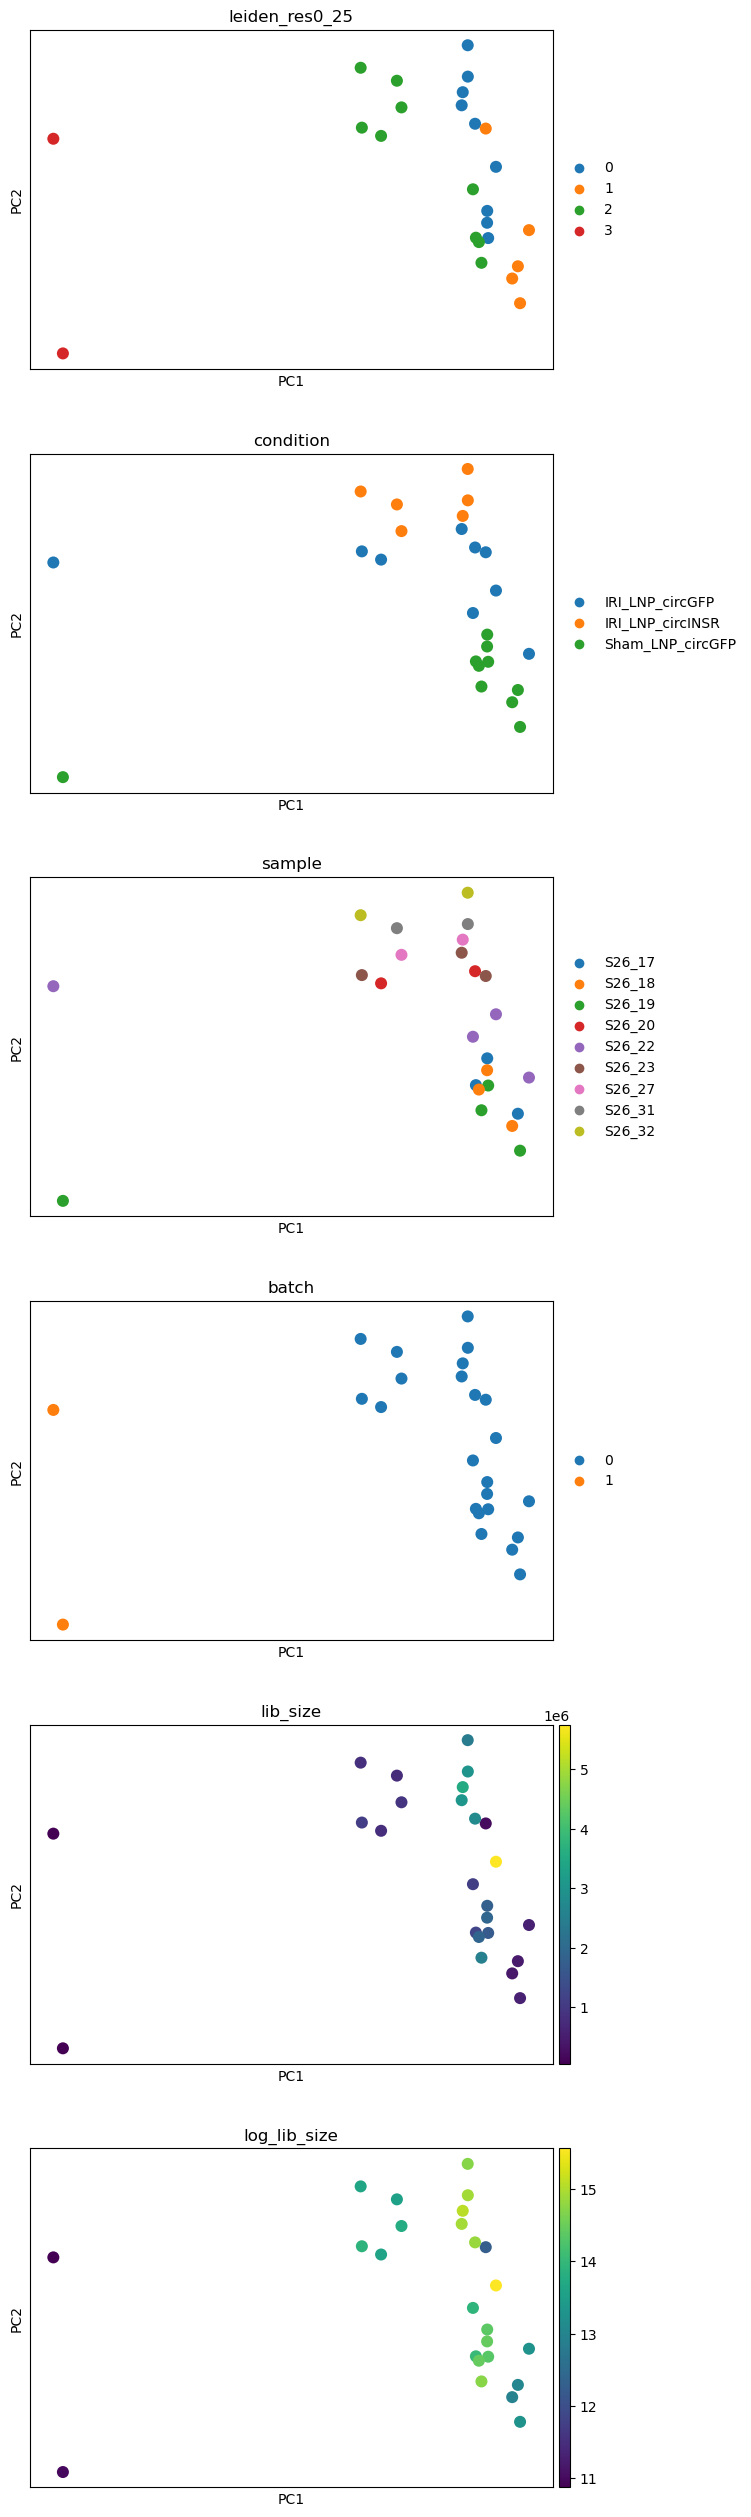

In [ ]:
# we are working with soupx counts, assigned to counts
adata_pb.layers['counts'] = adata_pb.X.copy()
sc.pp.normalize_total(adata_pb, target_sum=1e6)
sc.pp.log1p(adata_pb)
sc.pp.pca(adata_pb)
adata_pb.obs["lib_size"] = np.sum(adata_pb.layers["counts"], axis=1).astype(float)
adata_pb.obs["log_lib_size"] = np.log(adata_pb.obs["lib_size"].astype(float))
sc.pl.pca(adata_pb, color=adata_pb.obs, ncols=1, size=300)

In [90]:
adata_pb.X = adata_pb.layers['counts'].astype(float).copy()

In [91]:
adata_0 = adata_pb[adata_pb.obs["leiden_res0_25"] == "0"].copy()
adata_0

AnnData object with n_obs × n_vars = 9 × 20681
    obs: 'leiden_res0_25', 'condition', 'sample', 'batch', 'lib_size', 'log_lib_size'
    uns: 'log1p', 'pca', 'leiden_res0_25_colors', 'condition_colors', 'sample_colors', 'batch_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [92]:
adata_pb.obs

,leiden_res0_25,condition,sample,batch,lib_size,log_lib_size
donor_S26_17_0-0-0-0,0,Sham_LNP_circGFP,S26_17,0,1772144.0,14.387701
donor_S26_18_0-0-0-0,0,Sham_LNP_circGFP,S26_18,0,1905895.0,14.460462
donor_S26_19_0-0-0-0,0,Sham_LNP_circGFP,S26_19,0,1660018.0,14.322339
donor_S26_20_0-0-0-0,0,IRI_LNP_circGFP,S26_20,0,2760698.0,14.830994
donor_S26_22_0-0-0-0,0,IRI_LNP_circGFP,S26_22,0,5743554.0,15.563589
donor_S26_23_0-0-0-0,0,IRI_LNP_circGFP,S26_23,0,3049885.0,14.930614
donor_S26_27_0-0-0-0,0,IRI_LNP_circINSR,S26_27,0,3517713.0,15.073322
donor_S26_31_0-0-0-0,0,IRI_LNP_circINSR,S26_31,0,2999735.0,14.914035
donor_S26_32_0-0-0-0,0,IRI_LNP_circINSR,S26_32,0,2426975.0,14.702156
donor_S26_17_0-1-0-0,1,Sham_LNP_circGFP,S26_17,0,453694.0,13.025178


In [ ]:
adata_0.layers["counts"] = adata_0.layers['counts'].astype(float)

In [ ]:
adata_0.obs_names = [
    name.split("_")[1] + "_" + name.split("_")[2] for name in adata_0.obs_names
]

In [95]:
adata_0.X

array([[  1.,  28.,  18., ...,  57., 390.,   3.],
       [  0.,  34.,  15., ...,  59., 433.,  13.],
       [  6.,  25.,  10., ...,  41., 364.,   2.],
       ...,
       [  1.,  13.,  37., ..., 242., 907.,  92.],
       [  5.,  10.,  41., ..., 230., 868.,  78.],
       [  2.,  13.,  26., ..., 195., 598.,  52.]], shape=(9, 20681))

In [ ]:
adata_0.write("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/adata_myeloid_cluster0.h5ad")

In [51]:
import anndata2ri
from rpy2.robjects import pandas2ri
%reload_ext rpy2.ipython
anndata2ri.set_ipython_converter()

In [4]:
adata_0 = sc.read_h5ad("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/adata_myeloid_cluster0.h5ad")

In [84]:
%%R
fit_model <- function(adata_){
    # create an edgeR object with counts and grouping factor
    y <- DGEList(assay(adata_, "X"), group = colData(adata_)$condition)
    # filter out genes with low counts
    print("Dimensions before subsetting:")
    print(dim(y))
    keep <- filterByExpr(y, min.total.count = 100, min.count = 20)
    y <- y[keep, , keep.lib.sizes=FALSE]
    print("Dimensions after subsetting:")
    print(dim(y))
    # normalize
    y <- calcNormFactors(y)
    # create a vector that is a concatenation of condition and cell type that we will later use with contrasts
    group <- paste0(colData(adata_)$condition, ".", colData(adata_)$leiden_res0_25)
    print(group)
    replicate <- colData(adata_)$sample
    # create a design matrix: here we have multiple donors so also consider that in the design matrix
    design <- model.matrix(~ 0 + group)
    print(design)
    # estimate dispersion
    y <- estimateDisp(y, design = design)
    # fit the model
    fit <- glmQLFit(y, design)
    return(list("fit"=fit, "design"=design, "y"=y))
}

In [85]:
%%R -i adata_0
library(edgeR)
outs <-fit_model(adata_0)
fit <- outs$fit
y <- outs$y

[1] "Dimensions before subsetting:"
[1] 20681     9
[1] "Dimensions after subsetting:"
[1] 10741     9
[1] "Sham_LNP_circGFP.0" "Sham_LNP_circGFP.0" "Sham_LNP_circGFP.0"
[4] "IRI_LNP_circGFP.0"  "IRI_LNP_circGFP.0"  "IRI_LNP_circGFP.0" 
[7] "IRI_LNP_circINSR.0" "IRI_LNP_circINSR.0" "IRI_LNP_circINSR.0"
  groupIRI_LNP_circGFP.0 groupIRI_LNP_circINSR.0 groupSham_LNP_circGFP.0
1                      0                       0                       1
2                      0                       0                       1
3                      0                       0                       1
4                      1                       0                       0
5                      1                       0                       0
6                      1                       0                       0
7                      0                       1                       0
8                      0                       1                       0
9                      0               

In [27]:
%%R
print(y)

An object of class "DGEList"
$counts
              17_0-0-0-0 18_0-0-0-0 19_0-0-0-0 20_0-0-0-0 22_0-0-0-0 23_0-0-0-0
0610009B22Rik         28         34         25         13         37         10
0610009E02Rik         18         15         10         28         64         19
0610009L18Rik         14         19         19          9         22          5
0610010K14Rik         23         38         41         20         59         22
0610030E20Rik        157        171        163        190        413        274
              27_0-0-0-0 31_0-0-0-0 32_0-0-0-0
0610009B22Rik         13         10         13
0610009E02Rik         37         41         26
0610009L18Rik         18         11          1
0610010K14Rik         19          8         12
0610030E20Rik        213        206        138
12380 more rows ...

$samples
                      group lib.size norm.factors
17_0-0-0-0 Sham_LNP_circGFP  1762722    1.0448892
18_0-0-0-0 Sham_LNP_circGFP  1891989    1.0898857
19_0-0-0-0 Sham_LNP_c

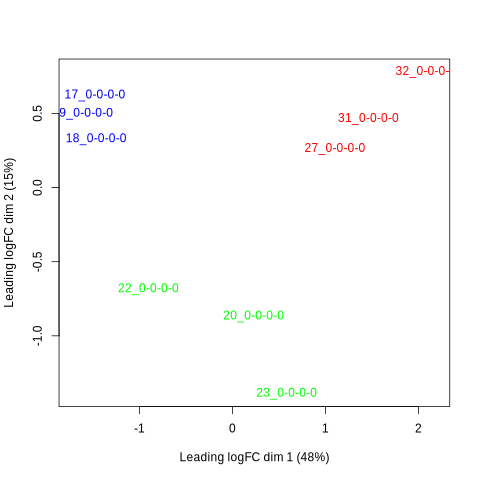

In [29]:
%%R
plotMDS(y, col=ifelse(y$samples$group == "Sham_LNP_circGFP",  "blue", ifelse(y$samples$group == "IRI_LNP_circGFP", "green", "red")))

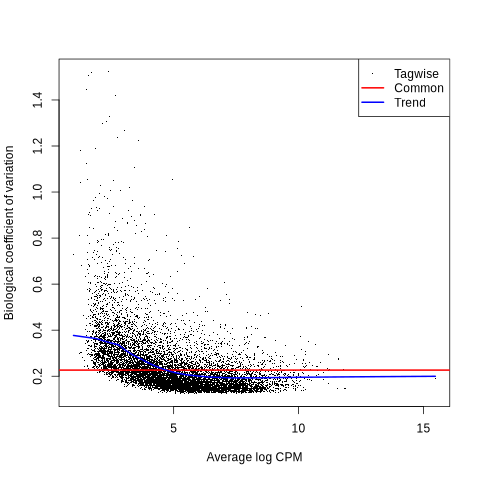

In [30]:
%%R
plotBCV(y)

In [31]:
%%R
colnames(y$design)

[1] "groupIRI_LNP_circGFP.0"  "groupIRI_LNP_circINSR.0"
[3] "groupSham_LNP_circGFP.0"


In [ ]:
%%R -o tt
# run the test for a specififed contrast
myContrast <- makeContrasts('groupIRI_LNP_circGFP.0-groupSham_LNP_circGFP.0', levels = y$design)
qlf <- glmQLFTest(fit, contrast=myContrast)
# get all of the DE genes and calculate Benjamini-Hochberg adjusted FDR
tt <- topTags(qlf, n = Inf)
tt <- tt$table


In [ ]:
%%R -o tt
# filter the results for FDR and logFC
library(dplyr)
print(head(tt))
print(typeof(tt))
tt <- as.data.frame(tt)
print(head(tt))
print(dim(tt[tt$FDR < 0.01,]))

tt_filtered <- tt %>%
  filter(FDR < 0.05 & (logFC > 1 | logFC < -1))

print(head(tt_filtered))
print(dim(tt_filtered))
print(tt["Ccr2", ])

            logFC   logCPM        F       PValue          FDR
Slfn3    2.733664 7.266639 217.8301 8.198790e-09 0.0001015420
Fbh1     1.953930 6.311553 148.4978 6.526054e-08 0.0001993527
Atg4a    2.691446 6.315576 146.2214 7.100137e-08 0.0001993527
Ddi2     1.837814 8.351132 145.0377 7.395680e-08 0.0001993527
Ubc     -1.560516 7.787942 142.1153 8.244706e-08 0.0001993527
Arhgap4 -2.053453 6.857059 131.4688 1.248346e-07 0.0001993527
[1] "list"
            logFC   logCPM        F       PValue          FDR
Slfn3    2.733664 7.266639 217.8301 8.198790e-09 0.0001015420
Fbh1     1.953930 6.311553 148.4978 6.526054e-08 0.0001993527
Atg4a    2.691446 6.315576 146.2214 7.100137e-08 0.0001993527
Ddi2     1.837814 8.351132 145.0377 7.395680e-08 0.0001993527
Ubc     -1.560516 7.787942 142.1153 8.244706e-08 0.0001993527
Arhgap4 -2.053453 6.857059 131.4688 1.248346e-07 0.0001993527
[1] 2589    5


            logFC   logCPM        F       PValue          FDR
Slfn3    2.733664 7.266639 217.8301 8.198790e-09 0.0001015420
Fbh1     1.953930 6.311553 148.4978 6.526054e-08 0.0001993527
Atg4a    2.691446 6.315576 146.2214 7.100137e-08 0.0001993527
Ddi2     1.837814 8.351132 145.0377 7.395680e-08 0.0001993527
Ubc     -1.560516 7.787942 142.1153 8.244706e-08 0.0001993527
Arhgap4 -2.053453 6.857059 131.4688 1.248346e-07 0.0001993527
[1] 4827    5
          logFC   logCPM         F    PValue       FDR
Ccr2 -0.1650021 5.914199 0.1080713 0.7482773 0.8160809


In [75]:
os.makedirs("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/DEG_testing", exist_ok=True)

In [ ]:
%%R
write.csv(tt_filtered,"/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/DEG_testing/Cluster0_DEGs_filtered_groupIRI_LNP_circGFP.0-groupSham_LNP_circGFP.0.csv", row.names = TRUE)
write.csv(tt,"/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/subcluster_myeloid_cells/DEG_testing/Cluster0_DEGs_unfiltered_groupIRI_LNP_circGPF.0-groupSham_LNP_circGFP.0.csv", row.names = TRUE)